Implements event classification in CICADA latent space

In [1]:
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
hep.style.use("CMS")
import h5py
from sklearn.manifold import TSNE

In [2]:
# ── Load data from HDF5 files ─────────────────────────────────────────────────

H5_DIR = "/scratch/network/lo8603/thesis/fast-ad/data/h5_files"

names = [
    "glugluhtogg",
    "glugluhtotautau",
    "hto2longlivedto4b",
    "singleneutrino",
    "suep",
    "tt",
    "vbfhto2b",
    "vbfhtotautau",
    "zb",
    "zprimetotautau",
    "zz",
]

latent_spaces   = {}
student_scores  = {}
npv             = {}

for name in names:
    with h5py.File(f"{H5_DIR}/{name}.h5", "r") as f:
        latent_spaces[name]  = f["teacher_latent"][:]
        student_scores[name] = f["student_score"][:]
        npv[name]            = f["nPV"][:]

# Convenience variables used by downstream cells
latent_space_glugluhtogg      = latent_spaces["glugluhtogg"]
latent_space_glugluhtotautau  = latent_spaces["glugluhtotautau"]
latent_space_hto2longlivedto4b= latent_spaces["hto2longlivedto4b"]
latent_space_singleneutrino   = latent_spaces["singleneutrino"]
latent_space_suep             = latent_spaces["suep"]
latent_space_tt               = latent_spaces["tt"]
latent_space_vbfhto2b         = latent_spaces["vbfhto2b"]
latent_space_vbfhtotautau     = latent_spaces["vbfhtotautau"]
latent_space_zb               = latent_spaces["zb"]
latent_space_zprimetotautau   = latent_spaces["zprimetotautau"]
latent_space_zz               = latent_spaces["zz"]

student_scores_glugluhtogg      = student_scores["glugluhtogg"]
student_scores_glugluhtotautau  = student_scores["glugluhtotautau"]
student_scores_hto2longlivedto4b= student_scores["hto2longlivedto4b"]
student_scores_singleneutrino   = student_scores["singleneutrino"]
student_scores_suep             = student_scores["suep"]
student_scores_tt               = student_scores["tt"]
student_scores_vbfhto2b         = student_scores["vbfhto2b"]
student_scores_vbfhtotautau     = student_scores["vbfhtotautau"]
student_scores_zb               = student_scores["zb"]
student_scores_zprimetotautau   = student_scores["zprimetotautau"]
student_scores_zz               = student_scores["zz"]

for name in names:
    print(f"{name:<22}  latent={latent_spaces[name].shape}  scores={student_scores[name].shape}")


glugluhtogg             latent=(1999756, 80)  scores=(1999756,)
glugluhtotautau         latent=(1999824, 80)  scores=(1999824,)
hto2longlivedto4b       latent=(157067, 80)  scores=(157067,)
singleneutrino          latent=(1999828, 80)  scores=(1999828,)
suep                    latent=(96275, 80)  scores=(96275,)
tt                      latent=(1999682, 80)  scores=(1999682,)
vbfhto2b                latent=(1716067, 80)  scores=(1716067,)
vbfhtotautau            latent=(1999799, 80)  scores=(1999799,)
zb                      latent=(1518845, 80)  scores=(1518845,)
zprimetotautau          latent=(190357, 80)  scores=(190357,)
zz                      latent=(1250094, 80)  scores=(1250094,)


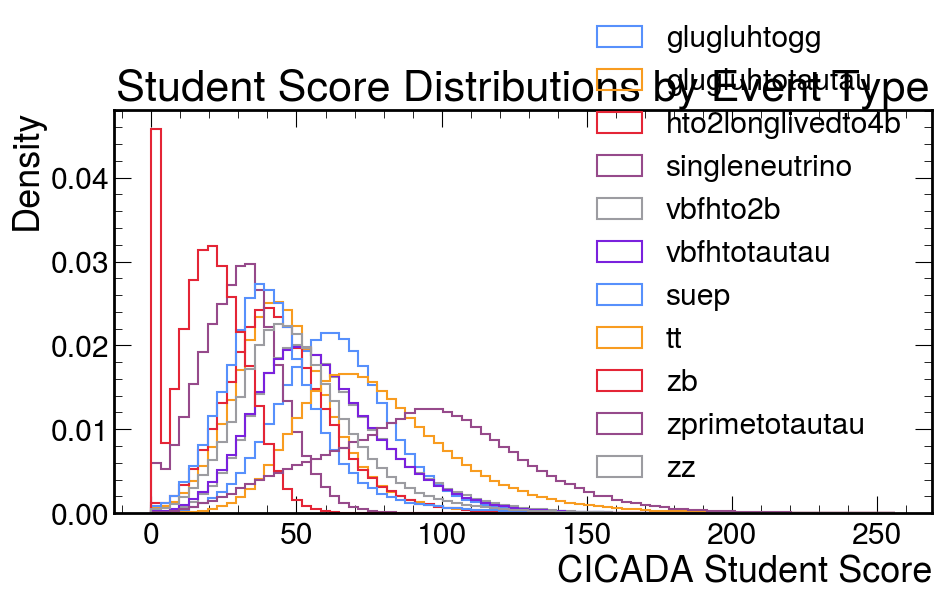

In [3]:
# visualize student scores

scores_dict = {
    "glugluhtogg":   student_scores_glugluhtogg,
    "glugluhtotautau":   student_scores_glugluhtotautau,
    "hto2longlivedto4b":   student_scores_hto2longlivedto4b,
    "singleneutrino": student_scores_singleneutrino,
    "vbfhto2b": student_scores_vbfhto2b,
    "vbfhtotautau": student_scores_vbfhtotautau,
    "suep":         student_scores_suep,
    "tt":       student_scores_tt,
    "zb":           student_scores_zb,
    "zprimetotautau": student_scores_zprimetotautau,
    "zz":       student_scores_zz
}

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(
    min(s.min() for s in scores_dict.values()),
    max(s.max() for s in scores_dict.values()),
    80
)

for label, scores in scores_dict.items():
    ax.hist(scores, bins=bins, histtype="step", linewidth=1.5, label=label, density=True)

ax.set_xlabel("CICADA Student Score")
ax.set_ylabel("Density")
ax.set_title("Student Score Distributions by Event Type")
ax.legend()
plt.tight_layout()
plt.show()

/scratch/network/lo8603/thesis/conda/envs/myenv/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


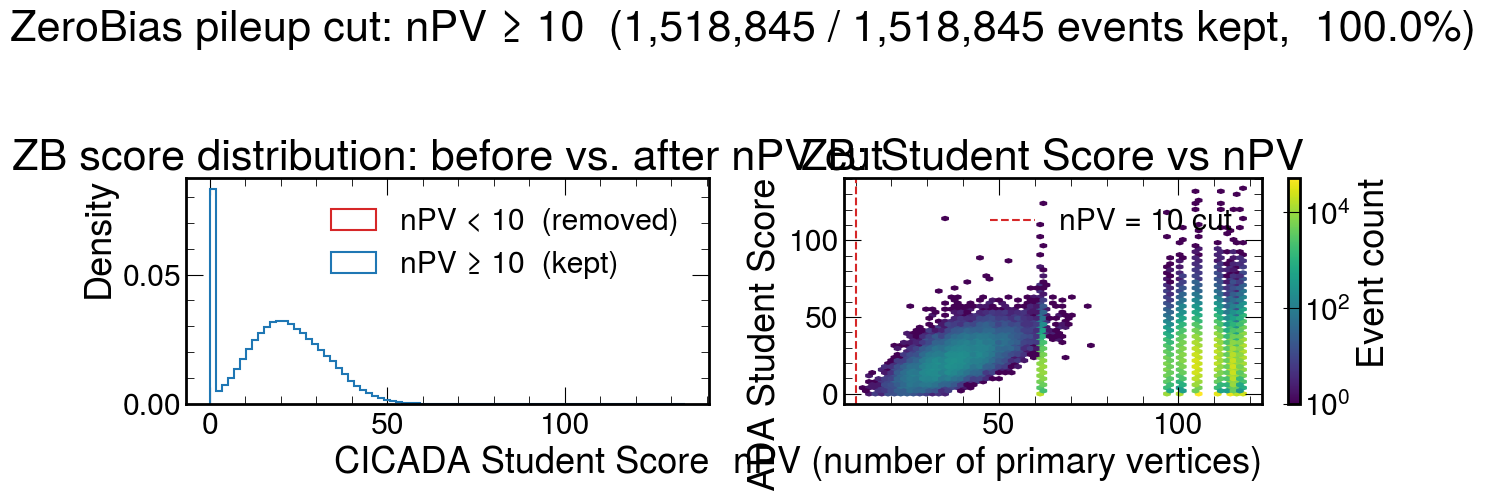

nPV threshold : 10
Events total  : 1,518,845
Events kept   : 1,518,845  (100.0%)
Events removed: 0  (0.0%)


In [4]:
# ── nPV cut visualisation (ZeroBias only) ─────────────────────────────────────
# nPV and student_score are both loaded from zb.h5 above.

NPV_THRESHOLD = 10   # must match MASK_THRESHOLD in root_to_hdf5.py / build_hdf5.py

npv_zb    = npv["zb"].astype(np.int32)
scores_zb = student_scores["zb"]

cut_pass = npv_zb >= NPV_THRESHOLD
cut_fail = ~cut_pass

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: score distributions split by nPV cut ────────────────────────────────
bins = np.linspace(scores_zb.min(), scores_zb.max(), 80)
axes[0].hist(scores_zb[cut_fail], bins=bins, histtype="step", linewidth=1.5,
             color="tab:red",  density=True, label=f"nPV < {NPV_THRESHOLD}  (removed)")
axes[0].hist(scores_zb[cut_pass], bins=bins, histtype="step", linewidth=1.5,
             color="tab:blue", density=True, label=f"nPV ≥ {NPV_THRESHOLD}  (kept)")
axes[0].set_xlabel("CICADA Student Score")
axes[0].set_ylabel("Density")
axes[0].set_title("ZB score distribution: before vs. after nPV cut")
axes[0].legend()

# ── Right: 2-D hexbin of score vs nPV ─────────────────────────────────────────
hb = axes[1].hexbin(npv_zb, scores_zb, gridsize=60, cmap="viridis",
                    mincnt=1, norm=LogNorm())
fig.colorbar(hb, ax=axes[1], label="Event count")
axes[1].axvline(NPV_THRESHOLD, color="tab:red", linewidth=1.5,
                linestyle="--", label=f"nPV = {NPV_THRESHOLD} cut")
axes[1].set_xlabel("nPV (number of primary vertices)")
axes[1].set_ylabel("CICADA Student Score")
axes[1].set_title("ZB: Student Score vs nPV")
axes[1].legend()

plt.suptitle(
    f"ZeroBias pileup cut: nPV ≥ {NPV_THRESHOLD}  "
    f"({cut_pass.sum():,} / {len(npv_zb):,} events kept,  "
    f"{100*cut_pass.mean():.1f}%)",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"nPV threshold : {NPV_THRESHOLD}")
print(f"Events total  : {len(npv_zb):,}")
print(f"Events kept   : {cut_pass.sum():,}  ({100*cut_pass.mean():.1f}%)")
print(f"Events removed: {cut_fail.sum():,}  ({100*cut_fail.mean():.1f}%)")


In [5]:
# ── Classifier imports ────────────────────────────────────────────────────────
# Set thread limits BEFORE importing TensorFlow to prevent MKL/OpenMP conflicts
import os
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["TF_NUM_INTEROP_THREADS"] = "4"
os.environ["TF_NUM_INTRAOP_THREADS"] = "8"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # disable oneDNN to avoid thread contention

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import xgboost as xgb

import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(8)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1775442530.060509 1776583 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# ── Data preparation ──────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

raw = {
    "glugluhtogg":      latent_space_glugluhtogg,
    "glugluhtotautau":  latent_space_glugluhtotautau,
    "hto2longlivedto4b":latent_space_hto2longlivedto4b,
    "singleneutrino":   latent_space_singleneutrino,
    "vbfhto2b":         latent_space_vbfhto2b,
    "vbfhtotautau":     latent_space_vbfhtotautau,
    "suep":             latent_space_suep,
    "tt":               latent_space_tt,
    "zb":               latent_space_zb,
    "zprimetotautau":   latent_space_zprimetotautau,
    "zz":               latent_space_zz,
}

class_names = list(raw.keys())
n_classes   = len(class_names)

# ── Balance classes to equal length (min class size) ─────────────────────────
min_len = min(len(v) for v in raw.values())
print(f"Min class size: {min_len:,} — truncating all classes to this.")
print(f"\n{'Class':<18} {'Total':>8} {'Kept':>8}")
print("-" * 36)
for name in class_names:
    print(f"{name:<18} {len(raw[name]):>8} {min_len:>8}")

# ── Stack into (N, 80) matrix — use float32 to halve memory vs float64 ───────
X = np.concatenate([v[:min_len].astype(np.float32) for v in raw.values()], axis=0)
y = np.concatenate([np.full(min_len, i, dtype=np.int32) for i in range(n_classes)])
print(f"\nTotal events: {len(y):,}  |  Latent dims: {X.shape[1]}")

# Free the large per-class arrays — train_test_split will make copies
del raw
import gc; gc.collect()

# ── Stratified train / val / test split (70 / 15 / 15) ───────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
del X, y  # free the unsplit arrays immediately
gc.collect()

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
del X_temp, y_temp
gc.collect()

print(f"Split → train: {len(y_train):,}, val: {len(y_val):,}, test: {len(y_test):,}")

# ── Standardise ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
del X_train, X_val, X_test  # keep only scaled versions
gc.collect()

# ── Class weights ─────────────────────────────────────────────────────────────
class_weights_arr    = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict    = dict(enumerate(class_weights_arr))
sample_weights_train = compute_sample_weight("balanced", y_train)

print("\nClass weights (should all be ~1.0 with balanced classes):")
for i, name in enumerate(class_names):
    print(f"  {name:<18} {class_weights_arr[i]:.3f}")

Min class size: 96,275 — truncating all classes to this.

Class                 Total     Kept
------------------------------------
glugluhtogg         1999756    96275
glugluhtotautau     1999824    96275
hto2longlivedto4b    157067    96275
singleneutrino      1999828    96275
vbfhto2b            1716067    96275
vbfhtotautau        1999799    96275
suep                  96275    96275
tt                  1999682    96275
zb                  1518845    96275
zprimetotautau       190357    96275
zz                  1250094    96275

Total events: 1,059,025  |  Latent dims: 80
Split → train: 741,317, val: 158,854, test: 158,854

Class weights (should all be ~1.0 with balanced classes):
  glugluhtogg        1.000
  glugluhtotautau    1.000
  hto2longlivedto4b  1.000
  singleneutrino     1.000
  vbfhto2b           1.000
  vbfhtotautau       1.000
  suep               1.000
  tt                 1.000
  zb                 1.000
  zprimetotautau     1.000
  zz                 1.000


: 

In [ ]:
# ── XGBoost baseline ──────────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cpu',
    nthread=8,               # explicit thread cap (takes priority over n_jobs)
    eval_metric="mlogloss",
    early_stopping_rounds=20,
    random_state=42,
)

xgb_model.fit(
    X_train_sc, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=50,
)

y_pred_xgb = xgb_model.predict(X_test_sc)
y_prob_xgb = xgb_model.predict_proba(X_test_sc)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print("\nXGBoost – test-set classification report:")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, digits=3))

[0]	validation_0-mlogloss:2.35868
[50]	validation_0-mlogloss:1.86071
[100]	validation_0-mlogloss:1.77087
[150]	validation_0-mlogloss:1.73167
[200]	validation_0-mlogloss:1.70751
[250]	validation_0-mlogloss:1.68990
[300]	validation_0-mlogloss:1.67618
[350]	validation_0-mlogloss:1.66520
[400]	validation_0-mlogloss:1.65633
[450]	validation_0-mlogloss:1.64875


Model: "latent_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               20736     
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 11)          

Epoch 1/300
1339/1339 [==============================] - 7s 4ms/step - loss: 1.8019 - accuracy: 0.3384 - val_loss: 1.6940 - val_accuracy: 0.3786
Epoch 2/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.7154 - accuracy: 0.3737 - val_loss: 1.6726 - val_accuracy: 0.3877
Epoch 3/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.6957 - accuracy: 0.3834 - val_loss: 1.6588 - val_accuracy: 0.3989
Epoch 4/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.6819 - accuracy: 0.3898 - val_loss: 1.6418 - val_accuracy: 0.4059
Epoch 5/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.6713 - accuracy: 0.3945 - val_loss: 1.6351 - val_accuracy: 0.4051
Epoch 6/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.6639 - accuracy: 0.3985 - val_loss: 1.6214 - val_accuracy: 0.4143
Epoch 7/300
1339/1339 [==============================] - 5s 4ms/step - loss: 1.6578 - accuracy: 0.4013 - val_loss: 1.6179 - val_ac

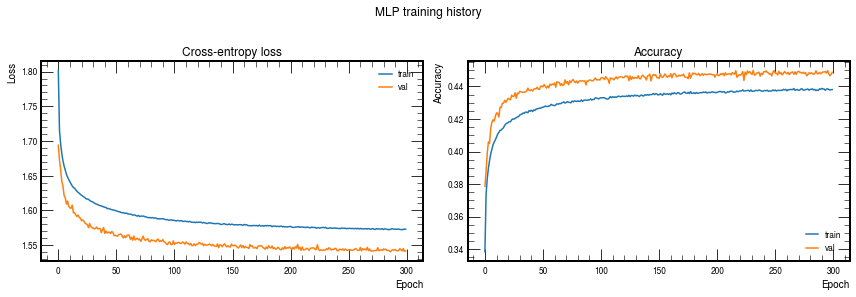

4589/4589 [==============================] - 6s 1ms/step

MLP – test-set classification report:
                   precision    recall  f1-score   support

      glugluhtogg      0.478     0.573     0.522     13347
  glugluhtotautau      0.236     0.277     0.255     13347
hto2longlivedto4b      0.264     0.187     0.219     13347
   singleneutrino      0.418     0.779     0.544     13347
         vbfhto2b      0.285     0.235     0.258     13347
     vbfhtotautau      0.275     0.101     0.148     13347
             suep      0.306     0.267     0.285     13347
               tt      0.426     0.614     0.503     13347
               zb      0.954     0.982     0.968     13347
   zprimetotautau      0.797     0.779     0.788     13347
               zz      0.258     0.140     0.182     13347

         accuracy                          0.449    146817
        macro avg      0.427     0.449     0.425    146817
     weighted avg      0.427     0.449     0.425    146817



In [ ]:
# ── MLP classifier ────────────────────────────────────────────────────────────
# Loss: sparse_categorical_crossentropy expects integer labels (not one-hot).

mlp = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_sc.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64,  activation="relu"),
    Dropout(0.2),
    Dense(n_classes, activation="softmax"),
], name="latent_classifier")

mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mlp.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history = mlp.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=300,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-entropy loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.suptitle("MLP training history", y=1.02)
plt.tight_layout()
plt.show()

y_prob_mlp = mlp.predict(X_test_sc)
y_pred_mlp = np.argmax(y_prob_mlp, axis=1)

print("\nMLP – test-set classification report:")
print(classification_report(y_test, y_pred_mlp, target_names=class_names, digits=3))

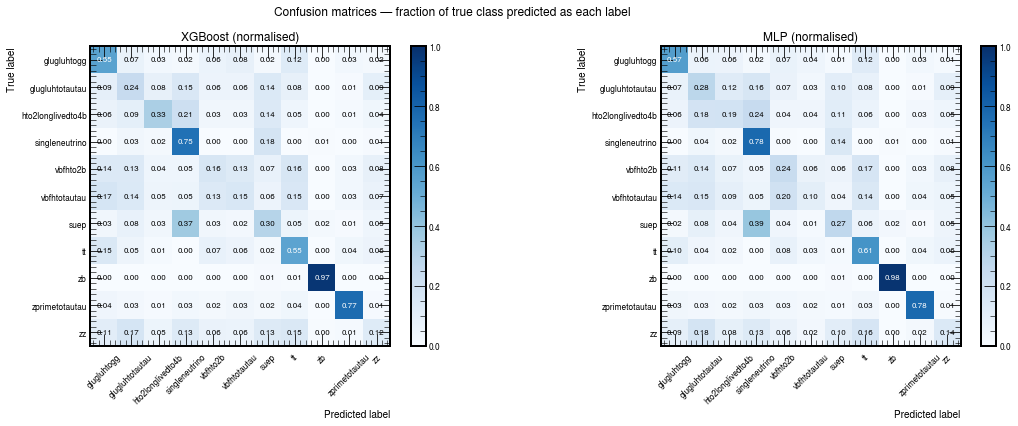

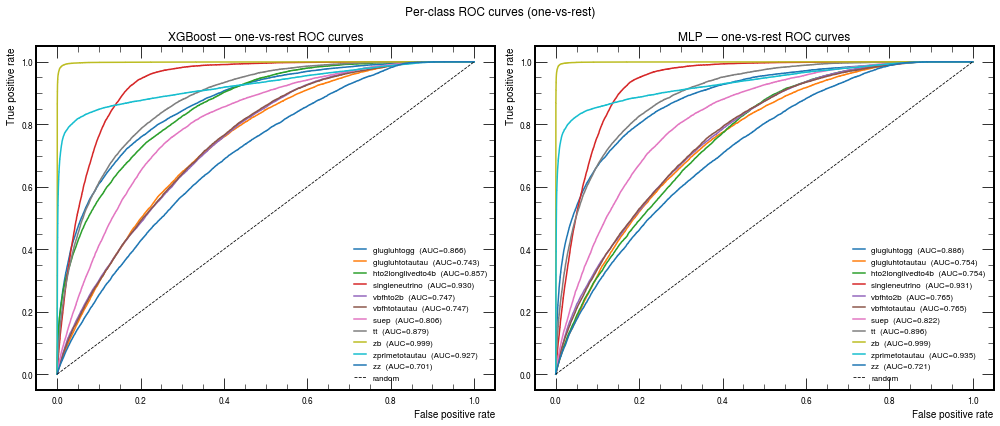

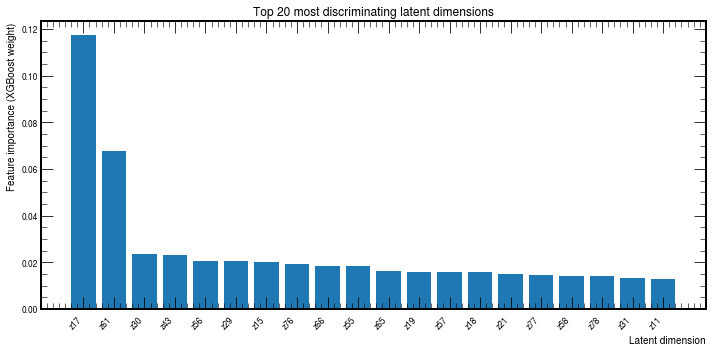

In [ ]:
# ── Evaluation: confusion matrices ────────────────────────────────────────────

def plot_confusion_matrix(cm, class_names, title, ax):
    """Plot a normalised confusion matrix on the given Axes."""
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=title,
    )
    ax.tick_params(axis="x", rotation=45)
    # Annotate each cell with its value
    thresh = 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    color=color, fontsize=8)

cm_xgb = confusion_matrix(y_test, y_pred_xgb, normalize="true")
cm_mlp = confusion_matrix(y_test, y_pred_mlp, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix(cm_xgb, class_names, "XGBoost (normalised)", axes[0])
plot_confusion_matrix(cm_mlp, class_names, "MLP (normalised)",     axes[1])
plt.suptitle("Confusion matrices — fraction of true class predicted as each label")
plt.tight_layout()
plt.show()

# ── Evaluation: per-class ROC curves (one-vs-rest) ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_prob, model_name in [
    (axes[0], y_prob_xgb, "XGBoost"),
    (axes[1], y_prob_mlp, "MLP"),
]:
    for k, name in enumerate(class_names):
        # Binary label: 1 if event belongs to class k, else 0
        y_bin = (y_test == k).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_prob[:, k])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f"{name}  (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name} — one-vs-rest ROC curves")
    ax.legend(fontsize=8)

plt.suptitle("Per-class ROC curves (one-vs-rest)")
plt.tight_layout()
plt.show()

# ── Evaluation: XGBoost feature importances ───────────────────────────────────

importances = xgb_model.feature_importances_   # 'weight' by default
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(top_n), importances[top_idx])
ax.set_xticks(np.arange(top_n))
ax.set_xticklabels([f"z{i}" for i in top_idx], rotation=45, ha="right")
ax.set_xlabel("Latent dimension")
ax.set_ylabel("Feature importance (XGBoost weight)")
ax.set_title(f"Top {top_n} most discriminating latent dimensions")
plt.tight_layout()
plt.show()

In [ ]:
# ── AUC bar chart (one-vs-rest, XGBoost vs MLP) ───────────────────────────────

aucs = {"XGBoost": [], "MLP": []}
for k in range(n_classes):
    y_bin = (y_test == k).astype(int)
    for label, y_prob in [("XGBoost", y_prob_xgb), ("MLP", y_prob_mlp)]:
        aucs[label].append(auc(*roc_curve(y_bin, y_prob[:, k])[:2]))

x = np.arange(n_classes)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_xgb = ax.bar(x - width/2, aucs["XGBoost"], width, label="XGBoost", color="tab:blue")
bars_mlp = ax.bar(x + width/2, aucs["MLP"],     width, label="MLP",     color="tab:orange")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("One-vs-rest AUC")
ax.set_title("Per-class AUC — latent space features")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="random")
ax.legend()

for bar in [*bars_xgb, *bars_mlp]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()